# Lab 5 · Red de incidencias, antenas, zonas y clientes afectados

Notebook preparado para **AWS Academy Learner Lab / SageMaker Notebook**. El objetivo es representar la red telco como un grafo, calcular métricas estructurales, estimar clientes afectados por la caída de nodos y cruzar la topología con incidencias.

Los CSV sintéticos incluidos respetan la estructura del laboratorio: `network_nodes.csv`, `network_edges.csv`, `customer_nodes.csv` y `network_incidents.csv`.

In [1]:
# Instalación de dependencias básicas. En SageMaker normalmente ya están instaladas.
%pip -q install pandas numpy matplotlib networkx scikit-learn s3fs

import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Por defecto se leen los CSV incluidos en la carpeta local data/.
# Si prefieres leer desde S3, cambia USE_S3=True y ajusta S3_PREFIX.
USE_S3 = False
DATA_DIR = Path('data')
S3_PREFIX = 's3://TU_BUCKET/TU_CARPETA'  # ejemplo: s3://mi-bucket/graph

def data_path(filename):
    return f"{S3_PREFIX}/{filename}" if USE_S3 else str(DATA_DIR / filename)

OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

import networkx as nx

Note: you may need to restart the kernel to use updated packages.


## Parte A. Cargar datos y construir el grafo

In [2]:
nodes = pd.read_csv(data_path('network_nodes.csv'))
edges = pd.read_csv(data_path('network_edges.csv'))
cust = pd.read_csv(data_path('customer_nodes.csv'))
inc = pd.read_csv(data_path('network_incidents.csv'))

print('Nodos:', nodes.shape)
print('Enlaces:', edges.shape)
print('Clientes:', cust.shape)
print('Incidencias:', inc.shape)
display(nodes.head())
display(edges.head())

Nodos: (50, 7)
Enlaces: (66, 5)
Clientes: (800, 4)
Incidencias: (60, 6)


,node_id,node_type,region,zone,capacity_gbps,lat,lon
0,CORE-01,core,Nacional,backbone,400,40.420000,-3.700000
1,CORE-02,core,Nacional,backbone,400,41.380000,2.170000
2,AGG-MAD,aggregation,Madrid,MAD-agregacion,120,40.441636,-3.710713
3,ACC-MAD-01,access,Madrid,MAD-zona-01,20,40.216662,-3.646398
4,ACC-MAD-02,access,Madrid,MAD-zona-02,10,40.701058,-3.565662


,source,target,link_type,capacity_gbps,distance_km
0,CORE-01,CORE-02,backbone,400,500.0
1,CORE-01,AGG-MAD,core-aggregation,120,99.2
2,CORE-02,AGG-MAD,core-aggregation,120,357.7
3,AGG-MAD,ACC-MAD-01,aggregation-access,30,10.7
4,AGG-MAD,ACC-MAD-02,aggregation-access,20,23.5


In [3]:
G = nx.Graph()
for _, r in nodes.iterrows():
    G.add_node(r['node_id'], node_type=r['node_type'], region=r['region'],
               zone=r['zone'], capacity=r['capacity_gbps'], lat=r['lat'], lon=r['lon'])
for _, r in edges.iterrows():
    G.add_edge(r['source'], r['target'], link_type=r['link_type'],
               capacity=r['capacity_gbps'], distance=r['distance_km'])

clientes_por_nodo = cust.groupby('access_node_id').size()
for nid in G.nodes():
    G.nodes[nid]['n_clientes'] = int(clientes_por_nodo.get(nid, 0))

print('Nodos en el grafo:', G.number_of_nodes())
print('Enlaces en el grafo:', G.number_of_edges())
print('¿Grafo conexo?:', nx.is_connected(G))
print('Clientes totales:', sum(nx.get_node_attributes(G, 'n_clientes').values()))

Nodos en el grafo: 50
Enlaces en el grafo: 66
¿Grafo conexo?: True
Clientes totales: 800


## Parte B. Métricas estructurales

Calculamos grado, centralidad de intermediación, cercanía y puntos de articulación.

In [4]:
grado = dict(G.degree())
bet = nx.betweenness_centrality(G)
clo = nx.closeness_centrality(G)

metricas = pd.DataFrame({
    'node_id': list(G.nodes()),
    'tipo': [G.nodes[n]['node_type'] for n in G.nodes()],
    'region': [G.nodes[n]['region'] for n in G.nodes()],
    'grado': [grado[n] for n in G.nodes()],
    'betweenness': [bet[n] for n in G.nodes()],
    'closeness': [clo[n] for n in G.nodes()],
    'clientes_directos': [G.nodes[n]['n_clientes'] for n in G.nodes()],
}).sort_values('betweenness', ascending=False)

display(metricas.head(12))

,node_id,tipo,region,grado,betweenness,closeness,clientes_directos
34,AGG-BIL,aggregation,Bilbao,11,0.285998,0.453704,0
10,AGG-BCN,aggregation,Barcelona,11,0.285147,0.453704,0
42,AGG-ZAR,aggregation,Zaragoza,11,0.285147,0.453704,0
18,AGG-VAL,aggregation,Valencia,11,0.285147,0.453704,0
2,AGG-MAD,aggregation,Madrid,11,0.285147,0.453704,0
26,AGG-SEV,aggregation,Sevilla,11,0.285147,0.453704,0
1,CORE-02,core,Nacional,7,0.190476,0.538462,0
0,CORE-01,core,Nacional,7,0.190476,0.538462,0
4,ACC-MAD-02,access,Madrid,2,0.000000,0.316129,25
3,ACC-MAD-01,access,Madrid,2,0.000000,0.316129,25


In [5]:
articulacion = list(nx.articulation_points(G))
print('Puntos de articulación:', len(articulacion))
for nid in articulacion:
    print(f"{nid:12s} | {G.nodes[nid]['node_type']:12s} | clientes directos: {G.nodes[nid]['n_clientes']}")

Puntos de articulación: 6
AGG-MAD      | aggregation  | clientes directos: 0
AGG-BCN      | aggregation  | clientes directos: 0
AGG-VAL      | aggregation  | clientes directos: 0
AGG-SEV      | aggregation  | clientes directos: 0
AGG-BIL      | aggregation  | clientes directos: 0
AGG-ZAR      | aggregation  | clientes directos: 0


## Parte C. Clientes afectados si cae un nodo

La función elimina temporalmente un nodo y comprueba qué nodos de acceso quedan desconectados del núcleo.

In [6]:
def clientes_afectados_si_cae(G, nodo):
    H = G.copy()
    clientes_directos = G.nodes[nodo].get('n_clientes', 0)
    H.remove_node(nodo)
    cores = [n for n in H.nodes() if H.nodes[n]['node_type'] == 'core']
    afectados = clientes_directos
    for nid, attr in H.nodes(data=True):
        if attr.get('n_clientes', 0) > 0:
            conectado = any(nx.has_path(H, nid, c) for c in cores) if cores else False
            if not conectado:
                afectados += attr['n_clientes']
    return int(afectados)

impacto = {n: clientes_afectados_si_cae(G, n) for n in G.nodes()}
resumen = metricas.set_index('node_id').copy()
resumen['clientes_afectados'] = pd.Series(impacto)
resumen = resumen.sort_values('clientes_afectados', ascending=False)
display(resumen.head(15))
resumen.to_csv(OUTPUT_DIR/'lab05_criticidad_nodos.csv')

,tipo,region,grado,betweenness,closeness,clientes_directos,clientes_afectados
node_id,,,,,,,
AGG-MAD,aggregation,Madrid,11,0.285147,0.453704,0,189
AGG-BCN,aggregation,Barcelona,11,0.285147,0.453704,0,176
AGG-ZAR,aggregation,Zaragoza,11,0.285147,0.453704,0,126
AGG-VAL,aggregation,Valencia,11,0.285147,0.453704,0,122
AGG-SEV,aggregation,Sevilla,11,0.285147,0.453704,0,103
AGG-BIL,aggregation,Bilbao,11,0.285998,0.453704,0,84
ACC-MAD-04,access,Madrid,1,0.000000,0.314103,49,49
ACC-BCN-06,access,Barcelona,1,0.000000,0.314103,40,40
ACC-ZAR-07,access,Zaragoza,2,0.000000,0.316129,30,30


## Parte D. Incidencias e impacto cliente × minuto

In [7]:
inc_nodo = inc.merge(nodes[['node_id','node_type','region','zone']], on='node_id', how='left')
inc_nodo['clientes_afectados'] = inc_nodo['node_id'].map(impacto)
inc_nodo['impacto_cliente_minuto'] = inc_nodo['clientes_afectados'] * inc_nodo['duration_minutes']

display(inc_nodo.groupby(['node_type','severity']).size().rename('incidencias').reset_index())
display(inc_nodo.sort_values('impacto_cliente_minuto', ascending=False).head(10))

resumen_region = inc_nodo.groupby('region').agg(
    incidencias=('incident_id','count'),
    minutos_totales=('duration_minutes','sum'),
    impacto=('impacto_cliente_minuto','sum')
).sort_values('impacto', ascending=False)
display(resumen_region)
inc_nodo.to_csv(OUTPUT_DIR/'lab05_incidencias_con_impacto.csv', index=False)

,node_type,severity,incidencias
0,access,critical,8
1,access,high,12
2,access,low,13
3,access,medium,17
4,aggregation,high,3
5,aggregation,low,3
6,aggregation,medium,4


,incident_id,node_id,incident_type,severity,duration_minutes,opened_at,node_type,region,zone,clientes_afectados,impacto_cliente_minuto
0,INC-0001,AGG-BCN,fiber_cut,high,121,2026-05-13 13:26:00,aggregation,Barcelona,BCN-agregacion,176,21296
43,INC-0044,AGG-ZAR,maintenance,high,91,2026-05-09 21:59:00,aggregation,Zaragoza,ZAR-agregacion,126,11466
46,INC-0047,AGG-ZAR,software,medium,76,2026-05-13 22:46:00,aggregation,Zaragoza,ZAR-agregacion,126,9576
55,INC-0056,AGG-ZAR,congestion,medium,69,2026-05-02 17:28:00,aggregation,Zaragoza,ZAR-agregacion,126,8694
42,INC-0043,AGG-BIL,congestion,high,96,2026-05-02 22:36:00,aggregation,Bilbao,BIL-agregacion,84,8064
35,INC-0036,AGG-ZAR,power,medium,57,2026-05-07 11:48:00,aggregation,Zaragoza,ZAR-agregacion,126,7182
1,INC-0002,ACC-VAL-04,power,critical,347,2026-05-08 01:59:00,access,Valencia,VAL-zona-04,20,6940
54,INC-0055,AGG-MAD,software,low,32,2026-05-21 17:23:00,aggregation,Madrid,MAD-agregacion,189,6048
9,INC-0010,ACC-SEV-05,power,critical,330,2026-05-03 12:40:00,access,Sevilla,SEV-zona-05,16,5280
33,INC-0034,AGG-SEV,fiber_cut,medium,44,2026-05-19 21:36:00,aggregation,Sevilla,SEV-agregacion,103,4532


,incidencias,minutos_totales,impacto
region,,,
Zaragoza,13,1011,47125
Barcelona,7,449,28361
Madrid,10,842,22682
Bilbao,15,1059,20771
Sevilla,10,1093,19945
Valencia,5,673,13095


## Parte E. Visualización de la red

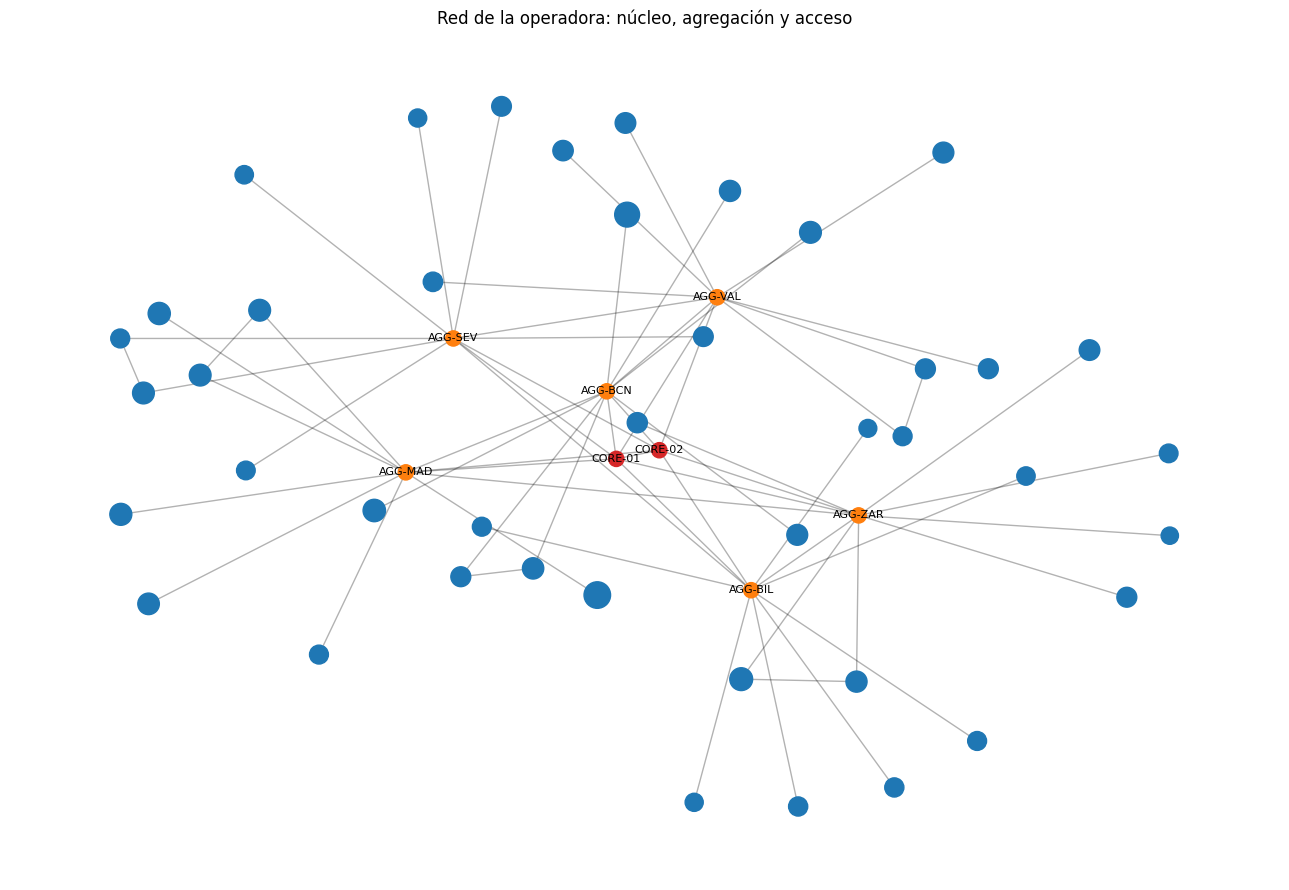

In [8]:
pos = nx.spring_layout(G, seed=42, k=0.5)
colors_by_type = {'core':'tab:red', 'aggregation':'tab:orange', 'access':'tab:blue'}
node_colors = [colors_by_type[G.nodes[n]['node_type']] for n in G.nodes()]
node_sizes = [120 + G.nodes[n]['n_clientes'] * 5 for n in G.nodes()]
labels = {n:n for n in G.nodes() if G.nodes[n]['node_type'] in ['core','aggregation']}

plt.figure(figsize=(13,9))
nx.draw_networkx_edges(G, pos, alpha=0.30)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes)
nx.draw_networkx_labels(G, pos, labels, font_size=8)
plt.title('Red de la operadora: núcleo, agregación y acceso')
plt.axis('off'); plt.tight_layout()
plt.savefig(OUTPUT_DIR/'lab05_red_por_tipo.png', dpi=150, bbox_inches='tight')
plt.show()

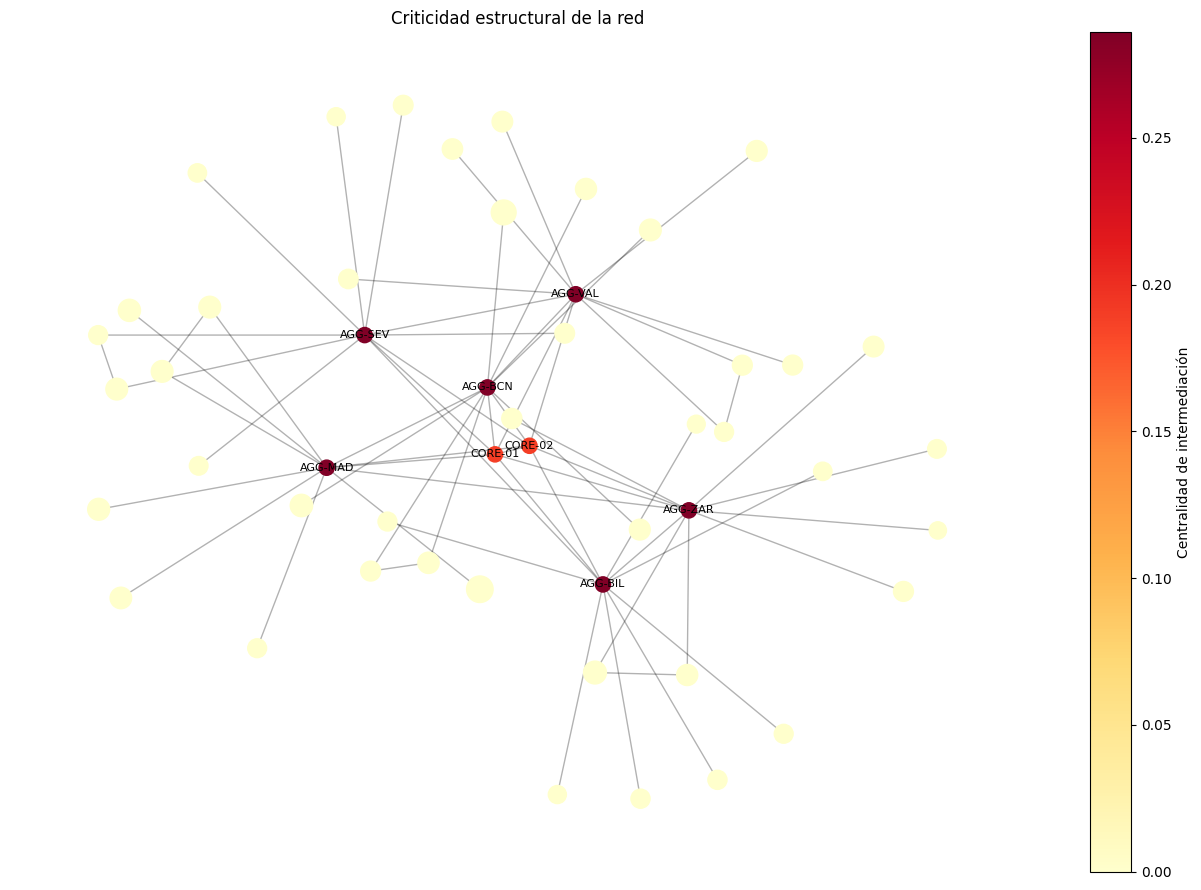

In [9]:
valores_bet = [bet[n] for n in G.nodes()]
plt.figure(figsize=(13,9))
nx.draw_networkx_edges(G, pos, alpha=0.30)
nodos = nx.draw_networkx_nodes(G, pos, node_color=valores_bet, cmap='YlOrRd', node_size=node_sizes)
plt.colorbar(nodos, label='Centralidad de intermediación')
nx.draw_networkx_labels(G, pos, labels, font_size=8)
plt.title('Criticidad estructural de la red')
plt.axis('off'); plt.tight_layout()
plt.savefig(OUTPUT_DIR/'lab05_criticidad_red.png', dpi=150, bbox_inches='tight')
plt.show()

## Cierre

Ficheros generados en `outputs/`: tabla de criticidad, incidencias con impacto y dos imágenes para el entregable.